# 动手学 AI：从单笔贷款到资产池的特征表示

本笔记本配套**第一章：美国抵押贷款市场与证券化大图景**中的“机器学习桥梁：从单笔贷款到资产池的特征表示”小节。

## 核心量化挑战
在二级抵押贷款市场中：
1. **杰克（Jack）与其他借款人**签署包含契约利率、FICO 信用分、LTV 杠杆率及本金余额的单笔贷款合同；
2. 放款机构（Maya）与 GSE（房利美 / 房地美）将数十笔至数千笔不同规模的异质性贷款打包为 MBS 资产池；
3. 二级市场交易员与投资人（Elena）必须对整个资产池的风险、久期及提前还款敏感度进行快速评估与对冲。

现代机器学习模型该如何表征并消化这样一个包含变长贷款记录、且排列顺序无关（置换不变性，Permutation Invariance）的资产池？

我们在本笔记本中构建并对比两大特征表征范式：
1. **经典人工加权汇总特征**：加权平均统计量（WAC、WALA、加权 FICO、加权 LTV、尾部风险占比、地理集中度 HHI）；
2. **Deep Sets 深度集合池化编码器（[Zaheer et al., NeurIPS 2017](https://arxiv.org/abs/1703.06114)）**：一种具备置换不变性的神经网络集合架构。先通过单笔贷款微观编码器 $\phi(x_i)$ 将借款人特征映射至隐空间，再通过本金余额加权池化 $z_{\text{pool}} = \sum_i w_i \phi(x_i)$ 得到资产池全局表征向量，最后由宏观解码器 $\rho(z_{\text{pool}})$ 端到端预测资产池层面的风险乘数 $\hat{y}$。


In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# 限制线程池防止小矩阵竞争
torch.set_num_threads(4)

# 设定随机种子以确保结果可精确复现
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.unicode_minus": False,
})

# 设置支持中文的字体
plt.rcParams["font.sans-serif"] = ["WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "Noto Sans CJK JP", "DejaVu Sans"]

print(f"PyTorch 版本: {torch.__version__} | 当前活跃 CPU 线程数: {torch.get_num_threads()}")


PyTorch 版本: 2.10.0+cu128 | 当前活跃 CPU 线程数: 4


## 1. 模拟异质性房贷资产池

我们模拟 300 个 MBS 资产池。每个资产池包含 40 到 80 笔微观特征各异的单笔抵押贷款：
- **UPB（未偿还本金余额）**：对数正态分布，平均约 30 万美元；
- **契约利率（Note Rate）**：围绕资产池所属 Vintage 基准利率分布；
- **FICO 信用分**：介于 620 至 820 分之间；
- **LTV（贷款价值比）**：介于 45% 至 97% 之间；
- **贷款账龄（Loan Age）**：借款人已还款月份数；
- **所在州（State）**：5 个典型地理区域之一。

**金融经济学真值逻辑**：
借款人的提前还款意愿是“息差转贷激励”与“信贷核保摩擦”的非线性协同产物。唯有那些既享有高利率激励，又具备优良信用（高 FICO、低 LTV）的借款人才能迅速转贷；而信用受损或房屋净值不足的借款人则被核保门槛锁死，转贷无门。


In [7]:
def generate_pools(n_pools=300, min_loans=40, max_loans=80, seed=SEED):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    pools = []
    pool_targets = []
    classical_features = []

    for pool_id in range(n_pools):
        m = rng.integers(min_loans, max_loans + 1)
        pool_base_rate = rng.uniform(0.058, 0.072)
        pool_avg_fico = rng.uniform(690, 760)

        # 单笔贷款属性
        upb = rng.lognormal(mean=12.6, sigma=0.4, size=m)
        rates = np.clip(rng.normal(pool_base_rate, 0.003, size=m), 0.050, 0.085)
        ficos = np.clip(rng.normal(pool_avg_fico, 35.0, size=m), 620, 820)
        ltvs = np.clip(rng.normal(74.0, 10.0, size=m), 45.0, 97.0)
        ages = np.clip(rng.poisson(lam=12.0, size=m), 1, 48)
        states = rng.choice(5, size=m, p=[0.25, 0.20, 0.18, 0.12, 0.25])

        # Deep Sets 所需的标准化单笔贷款特征矩阵
        state_one_hot = np.eye(5)[states]
        norm_loan_features = np.column_stack([
            (rates - 0.065) * 100.0,    # 相对于 6.5% 的利差（百分点）
            (ficos - 720.0) / 100.0,
            (ltvs - 75.0) / 10.0,
            ages / 12.0,
            state_one_hot,
        ])

        # 本金余额权重
        weights = upb / np.sum(upb)

        # --- 经典加权汇总特征 ---
        wac = np.sum(weights * rates) * 100.0
        wala = np.sum(weights * ages)
        w_fico = np.sum(weights * ficos)
        w_ltv = np.sum(weights * ltvs)
        low_fico_share = np.sum(weights * (ficos < 680))
        high_ltv_share = np.sum(weights * (ltvs > 80))
        state_shares = np.array([np.sum(weights[states == s]) for s in range(5)])
        hhi = np.sum(state_shares ** 2)

        classical_vec = [
            wac, wala, (w_fico - 720.0) / 100.0, (w_ltv - 75.0) / 10.0,
            low_fico_share, high_ltv_share, hhi,
        ]

        # --- 金融真值目标：非线性提前还款敏感度乘数 ---
        loan_refi_pot = np.maximum(0.0, rates - 0.060) * 100.0
        credit_friction = 1.0 / (1.0 + np.exp(-(ficos - 680.0) / 25.0)) * (1.0 / (1.0 + np.exp((ltvs - 82.0) / 5.0)))
        loan_true_speeds = 1.0 + 2.5 * loan_refi_pot * credit_friction
        pool_target = float(np.sum(weights * loan_true_speeds)) + rng.normal(0.0, 0.04)

        pools.append({
            "loan_features": torch.tensor(norm_loan_features, dtype=torch.float32),
            "weights": torch.tensor(weights, dtype=torch.float32).unsqueeze(-1),
            "upb": upb,
            "m_loans": m,
        })
        pool_targets.append(pool_target)
        classical_features.append(classical_vec)

    return (
        pools,
        torch.tensor(classical_features, dtype=torch.float32),
        torch.tensor(pool_targets, dtype=torch.float32).unsqueeze(-1),
    )

pools, classical_x, y = generate_pools(n_pools=300)
n_train = 240
train_pools, test_pools = pools[:n_train], pools[n_train:]
x_class_train, x_class_test = classical_x[:n_train], classical_x[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(f"成功生成 {len(pools)} 个资产池（{n_train} 个训练集，{len(test_pools)} 个留出测试集）。")
print(f"资产池 #0 概况: 包含 {pools[0]['m_loans']} 笔贷款，总本金规模: ${np.sum(pools[0]['upb']):,.0f}")
print(f"  经典汇总指标: WAC={classical_x[0, 0]:.2f}%, WALA={classical_x[0, 1]:.1f} 个月, 高 LTV 占比={classical_x[0, 5]*100:.1f}%, 区域 HHI={classical_x[0, 6]:.3f}")


成功生成 300 个资产池（240 个训练集，60 个留出测试集）。
资产池 #0 概况: 包含 43 笔贷款，总本金规模: $13,728,012
  经典汇总指标: WAC=6.41%, WALA=11.8 个月, 高 LTV 占比=23.7%, 区域 HHI=0.207


## 2. 范式一：经典加权汇总特征 MLP

在传统量化交易中，交易员将披露文件压缩为一个 1 维汇总统计向量：
$$x_{\text{classical}} = [\text{WAC}, \text{WALA}, \text{加权 FICO}, \text{加权 LTV}, \text{低 FICO 占比}, \text{高 LTV 占比}, \text{区域 HHI}]$$

我们在此向量上训练一个两层多层感知机（MLP）。


In [3]:
class ClassicalMLP(nn.Module):
    def __init__(self, in_features=7, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
model_classical = ClassicalMLP(in_features=classical_x.shape[1], hidden_dim=32)
opt_class = torch.optim.Adam(model_classical.parameters(), lr=0.01)

losses_class = []
for epoch in range(1, 401):
    opt_class.zero_grad()
    loss = F.mse_loss(model_classical(x_class_train), y_train)
    loss.backward()
    opt_class.step()
    if epoch % 50 == 0:
        losses_class.append((epoch, float(loss.detach())))

with torch.no_grad():
    test_pred_class = model_classical(x_class_test)
    rmse_class = math.sqrt(F.mse_loss(test_pred_class, y_test).item())

print(f"经典汇总特征 MLP 样本外测试集 RMSE: {rmse_class:.4f}")


经典汇总特征 MLP 样本外测试集 RMSE: 0.1425


## 3. 范式二：Deep Sets 深度集合池化编码器

深度集合定理（Zaheer 等人在 NeurIPS 2017 论文 [Deep Sets](https://arxiv.org/abs/1703.06114) 中给出的定理 2）表明，定义在集合 $\{x_1, \dots, x_M\}$ 上的置换不变函数可以写成：
$$f(\{x_1, \dots, x_M\}) = \rho\left( \sum_{i=1}^M w_i \, \phi(x_i) \right)$$

在抵押贷款证券化金融场景中：
- $\phi(x_i)$：单笔贷款编码器，将杰克的多维信贷特征映射为 16 维连续嵌入向量，在聚合发生前充分提炼“高息差 $\times$ 高信用”的协同作用；
- $w_i = \text{UPB}_i / \sum_j \text{UPB}_j$：贷款本金权重；
- $z_{\text{pool}} = \sum_i w_i \phi(x_i)$：学习得到的固定维度资产池嵌入表征；
- $\rho(z_{\text{pool}})$：资产池宏观解码器。

两条限定：其一，原定理只在元素取值可数时严格成立。对 FICO、LTV 这类连续特征，[Wagstaff 等人（ICML 2019）](https://arxiv.org/abs/1901.09006) 证明精确分解要求隐向量维度至少等于集合最大规模；[Tabaghi 与 Wang（ALT 2024）](https://arxiv.org/abs/2310.13829) 证明有限精度数据上 $2DN$ 维就够；[Wang 等人（ICLR 2024）](https://arxiv.org/abs/2307.04001) 证明所需宽度只随 $N$、$D$ 多项式增长；[Amir 等人（NeurIPS 2023）](https://arxiv.org/abs/2306.06529) 证明 GELU 这类光滑非多项式激活能区分任意两个集合，而 ReLU 这类分段线性激活不能——这正是下面代码选 GELU 的理论依据；下界仍在收紧（[Syed 等人 2026 年预印本](https://arxiv.org/abs/2605.08377)）。几千笔贷款的资产池按这些保证需要几万维，远不止这里的 16 维，所以定理说明的是架构形状对，小编码器够不够用要靠验证数据回答。其二，原定理的求和不加权，按本金占比加权是针对抵押贷款的改造。


In [4]:
class DeepSetsPoolEncoder(nn.Module):
    def __init__(self, in_loan_features=9, latent_dim=16, hidden_dim=32):
        super().__init__()
        # 单笔贷款微观编码器 phi
        self.phi = nn.Sequential(
            nn.Linear(in_loan_features, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        # 资产池宏观解码器 rho
        self.rho = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward_single_pool(self, loan_features, weights):
        loan_embeddings = self.phi(loan_features)
        pool_embedding = torch.sum(weights * loan_embeddings, dim=0, keepdim=True)
        return self.rho(pool_embedding)

    def forward(self, pool_batch):
        preds = [self.forward_single_pool(p["loan_features"], p["weights"]) for p in pool_batch]
        return torch.cat(preds, dim=0)

torch.manual_seed(SEED)
model_deepsets = DeepSetsPoolEncoder(in_loan_features=9, latent_dim=16, hidden_dim=32)
opt_ds = torch.optim.Adam(model_deepsets.parameters(), lr=0.005)

losses_ds = []
for epoch in range(1, 401):
    opt_ds.zero_grad()
    loss = F.mse_loss(model_deepsets(train_pools), y_train)
    loss.backward()
    opt_ds.step()
    if epoch % 50 == 0:
        losses_ds.append((epoch, float(loss.detach())))

with torch.no_grad():
    test_pred_ds = model_deepsets(test_pools)
    rmse_ds = math.sqrt(F.mse_loss(test_pred_ds, y_test).item())

print(f"Deep Sets 深度集合编码器样本外测试集 RMSE: {rmse_ds:.4f}")
print(f"相比经典汇总特征的相对误差缩减: {((rmse_class - rmse_ds)/rmse_class)*100:.1f}%")


Deep Sets 深度集合编码器样本外测试集 RMSE: 0.0593
相比经典汇总特征的相对误差缩减: 58.4%


## 4. 实证评估与可视化对比

我们将两类模型在完全独立的样本外测试集上的预测结果与金融真值进行对比制图。


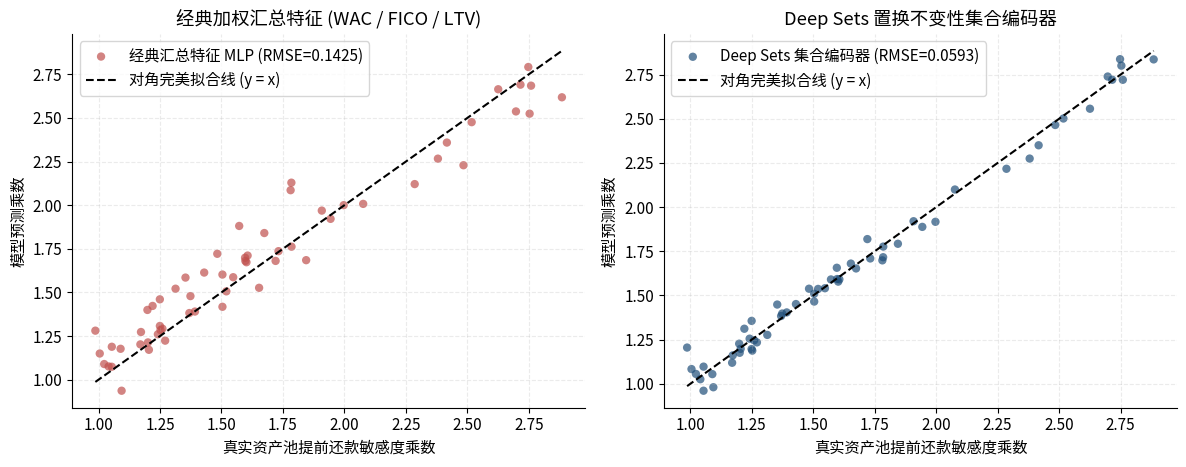

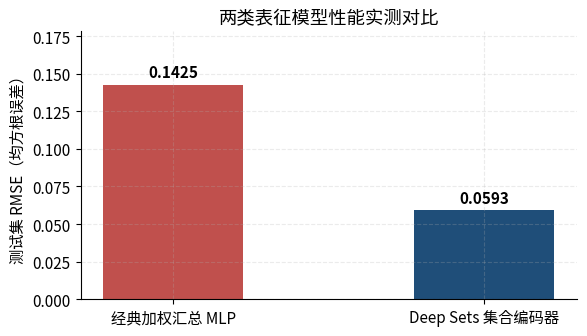

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

y_test_np = y_test.numpy().flatten()
pred_class_np = test_pred_class.numpy().flatten()
pred_ds_np = test_pred_ds.numpy().flatten()

# 散点图 1: 经典汇总特征 MLP
ax1.scatter(y_test_np, pred_class_np, color="#c0504d", alpha=0.7, edgecolors="none", s=36, label=f"经典汇总特征 MLP (RMSE={rmse_class:.4f})")
ax1.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "k--", lw=1.5, label="对角完美拟合线 (y = x)")
ax1.set_xlabel("真实资产池提前还款敏感度乘数")
ax1.set_ylabel("模型预测乘数")
ax1.set_title("经典加权汇总特征 (WAC / FICO / LTV)")
ax1.legend(frameon=True)

# 散点图 2: Deep Sets 集合编码器
ax2.scatter(y_test_np, pred_ds_np, color="#1f4e79", alpha=0.7, edgecolors="none", s=36, label=f"Deep Sets 集合编码器 (RMSE={rmse_ds:.4f})")
ax2.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "k--", lw=1.5, label="对角完美拟合线 (y = x)")
ax2.set_xlabel("真实资产池提前还款敏感度乘数")
ax2.set_ylabel("模型预测乘数")
ax2.set_title("Deep Sets 置换不变性集合编码器")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

# 性能对比柱状图
fig, ax = plt.subplots(figsize=(6, 3.5))
models = ["经典加权汇总 MLP", "Deep Sets 集合编码器"]
rmses = [rmse_class, rmse_ds]
colors = ["#c0504d", "#1f4e79"]
bars = ax.bar(models, rmses, color=colors, width=0.45)
ax.set_ylabel("测试集 RMSE（均方根误差）")
ax.set_title("两类表征模型性能实测对比")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, max(rmses) * 1.25)
plt.tight_layout()
plt.show()


## 5. 交易台实务量化启示

1. **一阶矩统计量的信息丢失**：人工汇总的统计量（WAC、WALA、加权平均 FICO/LTV）只描述了边缘分布的一阶矩。两个资产池可以拥有完全相同的 6.50% WAC 与 740 平均 FICO，但一个池子可能将高息差集中在低信用借款人手中（被卡住），另一个池子可能将高息差集中在高信用借款人手中（即将秒转贷）。经典统计量对此完全盲目。
2. **置换不变性与集合表达**：Deep Sets 架构天生契合抵押贷款披露文件的可交换性本质：贷款在披露文件中的排列顺序在经济学上没有任何区别。
3. **交易台落地价值**：在二级交易台（Elena）对定制化大宗全贷款资产包（Bulk Whole Loans）进行快速相对价值扫描与对冲时，Deep Sets 表征能够实现端到端毫秒级推断，且不损失底层借款人的微观异质性。
